# 00 EDA：月总量、同比环比、滚动趋势与预测锚点节奏

本 notebook 面向 `30d-jenny` 月末总量预测任务，按顶部配置的数据月份范围做 EDA。每个主要 block 尽量保持“一份表格数据 + 一个时序图”的展示方式；不适合画时序图的总结 block 会改用 summary 表。

预测业务只关注两个锚点：每个月倒数第 10 个工作日预测全月，以及倒数第 5 个工作日预测全月。因此，月末相关分析只保留这两个锚点，不扩展其它月末时间窗口。


## Block 0：环境与通用函数

统一加载依赖、路径、格式化函数和绘图风格。工作日优先使用 `chinese_calendar`；如果环境未安装，则退回周一到周五口径，并在输出中明确提示。

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "grid.color": "#e8e8e8",      # 背景参考线更浅
        "grid.linewidth": 0.7,
        "grid.alpha": 0.45,
        "axes.edgecolor": "#d6d6d6",
        "axes.linewidth": 0.8,
    },
)

mpl.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 160,          # notebook 显示分辨率更高
    "savefig.dpi": 300,         # 保存图片分辨率更高
    "savefig.bbox": "tight",
    "axes.unicode_minus": False,
})

preferred_fonts = [
    "PingFang SC", "Hiragino Sans GB", "Microsoft YaHei", "Heiti SC",
    "Arial Unicode MS", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"
]
for font in preferred_fonts:
    plt.rcParams["font.sans-serif"] = [font] + plt.rcParams.get("font.sans-serif", [])

# 时间范围超参：None 表示使用数据全集；否则填写 YYYYMM，例如 202301。
START_YYYYMM = 202401
END_YYYYMM = None

DATA_FILE = Path("data/sales_daily.csv")
DATA_DIR_CANDIDATES = [Path("."), Path("../.."), Path("code/30d-jenny")]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if (p / DATA_FILE).exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Cannot find data/sales_daily.csv from current working directory, repo root, or code/30d-jenny")

DAILY_PATH = DATA_DIR / DATA_FILE
TRAIN_PATH = DATA_DIR / "train.csv"
VALID_PATH = DATA_DIR / "valid.csv"
TEST_PATH = DATA_DIR / "test.csv"

try:
    from chinese_calendar import is_workday as cn_is_workday
    WORKDAY_SOURCE = "chinese_calendar"
    def is_business_workday(ts):
        return bool(cn_is_workday(pd.Timestamp(ts).date()))
except Exception:
    WORKDAY_SOURCE = "weekday_fallback_Mon_Fri"
    def is_business_workday(ts):
        return pd.Timestamp(ts).weekday() < 5

TARGET_YEARS = []
TARGET_YEAR_LABEL = ""
YOY_COMPARE_ORDER = []
ANCHOR_OFFSETS = [10, 5]
MONTH_ORDER = list(range(1, 13))
YEAR_COLORS = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860", "#64b5cd", "#8c8c8c"]
COMPARE_COLORS = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860", "#64b5cd", "#8c8c8c"]


def parse_yyyymm(value, name):
    if value is None or value == "":
        return None, None
    value = str(value)
    if len(value) != 6 or not value.isdigit():
        raise ValueError(f"{name} must be None or YYYYMM, got {value!r}")
    ts = pd.to_datetime(value + "01", format="%Y%m%d")
    return int(value), ts


def get_year_color(year):
    if year in TARGET_YEARS:
        return YEAR_COLORS[TARGET_YEARS.index(year) % len(YEAR_COLORS)]
    return YEAR_COLORS[0]


def get_compare_color(compare):
    if compare in YOY_COMPARE_ORDER:
        return COMPARE_COLORS[YOY_COMPARE_ORDER.index(compare) % len(COMPARE_COLORS)]
    return COMPARE_COLORS[0]


def fmt_num(x):
    if pd.isna(x):
        return ""
    return f"{x:,.0f}"


def fmt_pct(x):
    if pd.isna(x):
        return ""
    return f"{x:.1%}"


def pct_series(s):
    return s.map(fmt_pct)


def display_table(df, caption=None):
    if caption:
        print(caption)
    display(df)


def add_year_boundaries(ax, month_df):
    year_starts = month_df.drop_duplicates("year")[["month_start", "year"]]
    ymin, ymax = ax.get_ylim()
    for _, row in year_starts.iterrows():
        ax.axvline(row["month_start"], color="0.75", linewidth=1, linestyle="--", alpha=0.8)
        ax.text(row["month_start"], ymax, str(int(row["year"])), va="top", ha="left", color="0.35", fontsize=10)
    ax.set_ylim(ymin, ymax)


def print_insights(items):
    for item in items:
        print(f"- {item}")

print(f"Data dir: {DATA_DIR.resolve()}")
print(f"Workday calendar source: {WORKDAY_SOURCE}")

Data dir: /Users/mark/Git/lab/ts-forecast
Workday calendar source: weekday_fallback_Mon_Fri


## Block 1：数据接入与质量检查

表格展示数据范围、完整性、缺失和异常概览；时序图展示日销量和医院数的原始趋势，先判断是否存在明显断点或极端冲击。

数据质量 summary


,metric,value
0,rows,1575
1,date_min,2022-01-01
2,date_max,2026-04-30
3,months,52
4,complete_months,49
5,incomplete_months,3
6,qty_missing,0
7,num_hosp_missing,0
8,qty_negative,2
9,num_hosp_negative,0


最近月份完整性检查


,month_start,bizym,year,month,date_min,date_max,observed_days,month_total,month_num_hosp_total,qty_missing,hosp_missing,qty_negative,hosp_negative,calendar_days,missing_calendar_days,is_complete_month
40,2025-05-01,202505,2025,5,2025-05-01,2025-05-31,31,"2,008,992.0000",11595,0,0,0,0,31,0,True
41,2025-06-01,202506,2025,6,2025-06-01,2025-06-30,30,"2,394,239.0000",12856,0,0,0,0,30,0,True
42,2025-07-01,202507,2025,7,2025-07-01,2025-07-31,31,"2,264,622.0000",13960,0,0,0,0,31,0,True
43,2025-08-01,202508,2025,8,2025-08-01,2025-08-31,31,"2,322,179.0000",13651,0,0,0,0,31,0,True
44,2025-09-01,202509,2025,9,2025-09-01,2025-09-30,30,"3,069,649.0000",16241,0,0,0,0,30,0,True
45,2025-10-01,202510,2025,10,2025-10-01,2025-10-31,31,"2,104,318.0000",12263,0,0,0,0,31,0,True
46,2025-11-01,202511,2025,11,2025-11-01,2025-11-30,30,"2,384,335.0000",13799,0,0,0,0,30,0,True
47,2025-12-01,202512,2025,12,2025-12-01,2025-12-31,31,"2,812,283.0000",15799,0,0,0,0,31,0,True
48,2026-01-01,202601,2026,1,2026-01-01,2026-01-31,31,"2,842,656.0000",15115,0,0,0,0,31,0,True
49,2026-02-01,202602,2026,2,2026-02-01,2026-02-28,26,"1,792,965.0000",10280,0,0,0,0,28,2,False


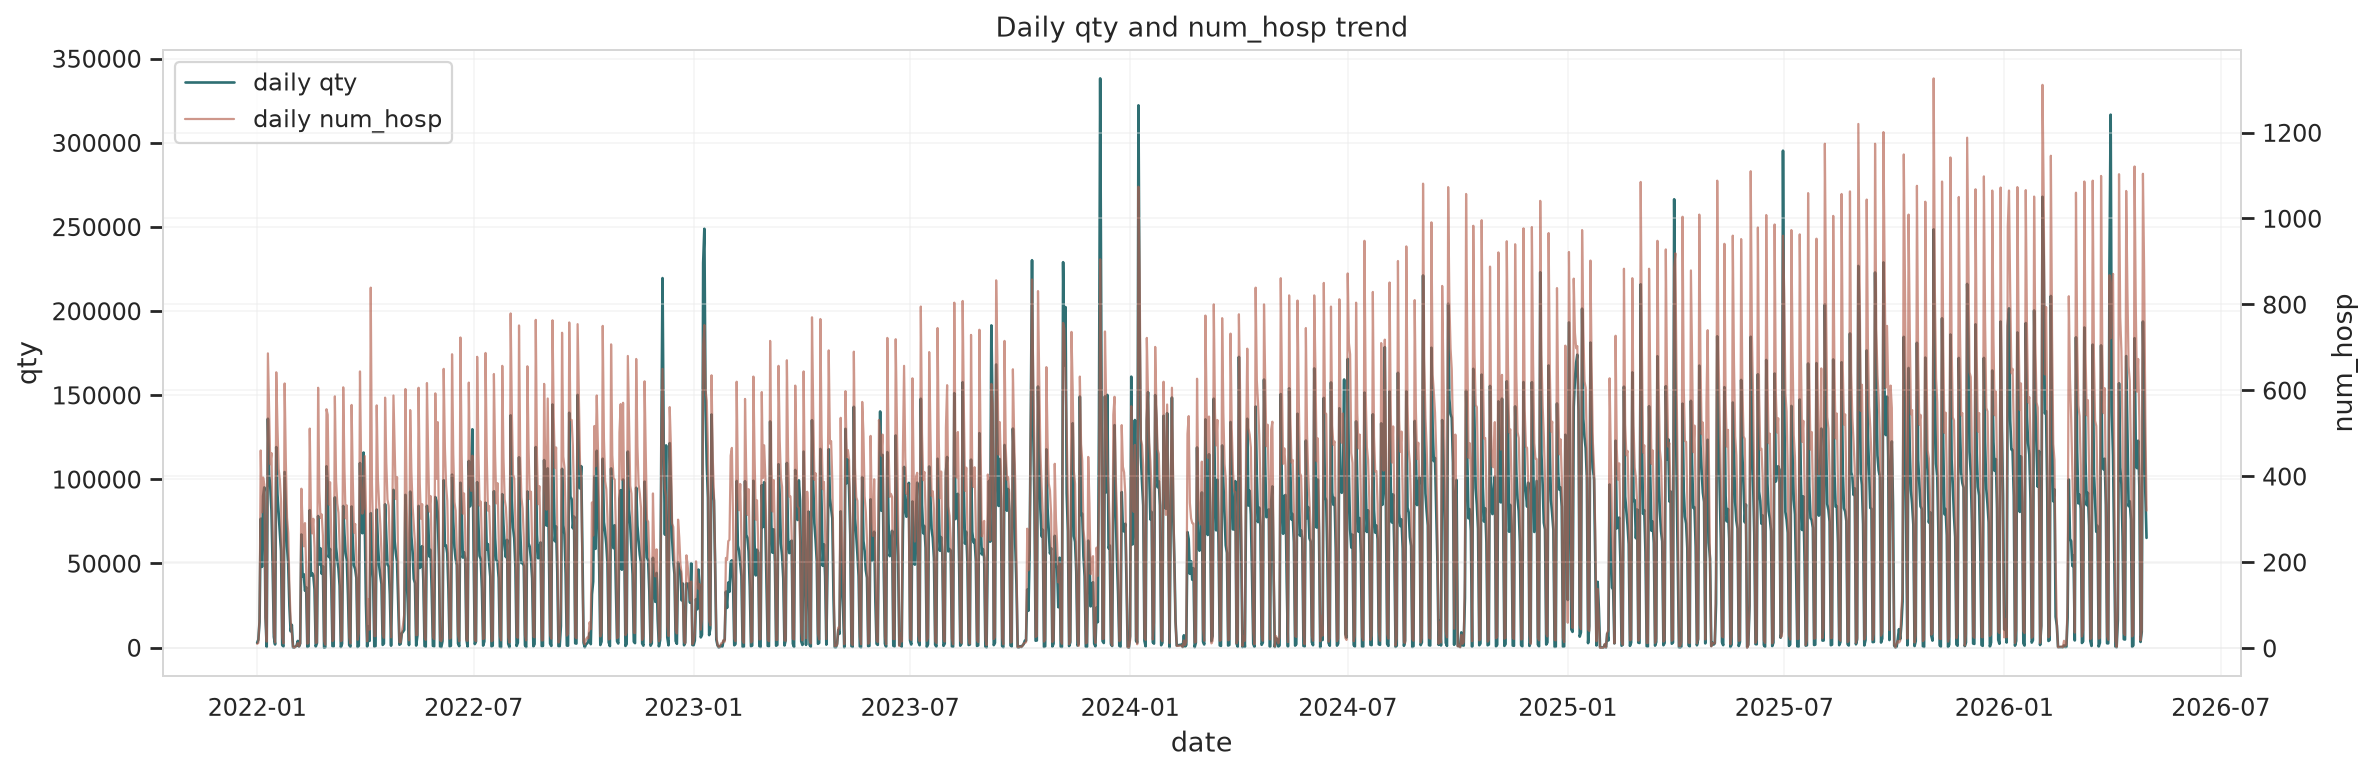

- 数据覆盖 2022-01-01 到 2026-04-30，共 52 个业务月份。
- 完整月份 49 个，不完整月份 3 个。
- 工作日口径使用 weekday_fallback_Mon_Fri；如果要严格贴合法定节假日，请在环境中安装 chinese_calendar 后重跑。


In [2]:
df_raw = pd.read_csv(DAILY_PATH)
df = df_raw.copy()
df["transdate"] = pd.to_datetime(df["transdate"])
df["bizym"] = df["bizym"].astype(int)

start_bizym, start_month = parse_yyyymm(START_YYYYMM, "START_YYYYMM")
end_bizym, end_month = parse_yyyymm(END_YYYYMM, "END_YYYYMM")
if start_bizym is not None and end_bizym is not None and start_bizym > end_bizym:
    raise ValueError("START_YYYYMM must be <= END_YYYYMM")
if start_bizym is not None:
    df = df[df["bizym"] >= start_bizym]
if end_bizym is not None:
    df = df[df["bizym"] <= end_bizym]
if df.empty:
    raise ValueError("No rows remain after applying START_YYYYMM / END_YYYYMM")

df["year"] = df["bizym"] // 100
df["month"] = df["bizym"] % 100
df["day_of_month"] = df["transdate"].dt.day
df["month_start"] = df["transdate"].dt.to_period("M").dt.to_timestamp()
df = df.sort_values(["transdate", "bizym"]).reset_index(drop=True)

month_range_start = start_month if start_month is not None else df["month_start"].min()
month_range_end = end_month if end_month is not None else df["month_start"].max()
complete_months = pd.period_range(month_range_start, month_range_end, freq="M")
complete_month_index = pd.DataFrame({"month_start": complete_months.to_timestamp()})
complete_month_index["bizym"] = complete_month_index["month_start"].dt.strftime("%Y%m").astype(int)
complete_month_index["year"] = complete_month_index["bizym"] // 100
complete_month_index["month"] = complete_month_index["bizym"] % 100

target_years = complete_month_index["year"].drop_duplicates().astype(int).tolist()
TARGET_YEARS[:] = target_years
TARGET_YEAR_LABEL = f"{TARGET_YEARS[0]}-{TARGET_YEARS[-1]}" if TARGET_YEARS else ""
YOY_COMPARE_ORDER[:] = [f"{year}_vs_{year - 1}" for year in TARGET_YEARS[1:]]

monthly_observed = (
    df.groupby(["bizym", "year", "month", "month_start"], as_index=False)
      .agg(
          date_min=("transdate", "min"),
          date_max=("transdate", "max"),
          observed_days=("transdate", "nunique"),
          month_total=("qty", "sum"),
          month_num_hosp_total=("num_hosp", "sum"),
          qty_missing=("qty", lambda s: s.isna().sum()),
          hosp_missing=("num_hosp", lambda s: s.isna().sum()),
          qty_negative=("qty", lambda s: (s < 0).sum()),
          hosp_negative=("num_hosp", lambda s: (s < 0).sum()),
      )
)
monthly_basic = complete_month_index.merge(
    monthly_observed,
    on=["bizym", "year", "month", "month_start"],
    how="left",
)
monthly_basic["observed_days"] = monthly_basic["observed_days"].fillna(0).astype(int)
for c in ["qty_missing", "hosp_missing", "qty_negative", "hosp_negative"]:
    monthly_basic[c] = monthly_basic[c].fillna(0).astype(int)
monthly_basic["calendar_days"] = monthly_basic["month_start"].dt.days_in_month
monthly_basic["missing_calendar_days"] = monthly_basic["calendar_days"] - monthly_basic["observed_days"]
monthly_basic["is_complete_month"] = monthly_basic["missing_calendar_days"].eq(0)

quality_summary = pd.DataFrame({
    "metric": [
        "rows", "date_min", "date_max", "months", "complete_months", "incomplete_months",
        "qty_missing", "num_hosp_missing", "qty_negative", "num_hosp_negative",
        "range_start_yyyymm", "range_end_yyyymm", "workday_calendar_source",
    ],
    "value": [
        len(df), df["transdate"].min().date(), df["transdate"].max().date(),
        monthly_basic["bizym"].nunique(), monthly_basic["is_complete_month"].sum(),
        (~monthly_basic["is_complete_month"]).sum(), df["qty"].isna().sum(),
        df["num_hosp"].isna().sum(), (df["qty"] < 0).sum(), (df["num_hosp"] < 0).sum(),
        START_YYYYMM, END_YYYYMM, WORKDAY_SOURCE,
    ]
})

display_table(quality_summary, "数据质量 summary")
display_table(monthly_basic.query("year in @TARGET_YEARS").tail(12), "最近月份完整性检查")

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(df["transdate"], df["qty"], color="#2f6f73", linewidth=1.2, label="daily qty")
ax1.set_title("Daily qty and num_hosp trend")
ax1.set_xlabel("date")
ax1.set_ylabel("qty")
ax2 = ax1.twinx()
ax2.plot(df["transdate"], df["num_hosp"], color="#b45f4d", linewidth=1.0, alpha=0.65, label="daily num_hosp")
ax2.set_ylabel("num_hosp")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")
plt.tight_layout()
plt.show()

insights = [
    f"数据覆盖 {df['transdate'].min().date()} 到 {df['transdate'].max().date()}，共 {monthly_basic['bizym'].nunique()} 个业务月份。",
    f"完整月份 {int(monthly_basic['is_complete_month'].sum())} 个，不完整月份 {int((~monthly_basic['is_complete_month']).sum())} 个。",
    f"工作日口径使用 {WORKDAY_SOURCE}；如果要严格贴合法定节假日，请在环境中安装 chinese_calendar 后重跑。",
]
print_insights(insights)


## Block 2：月总量平铺表

表格按所选数据范围内的自然年和 1 到 12 月十二列平铺月总量；时序图按月份连续展示月总量，缺失月份保留为空，不补零。


2022-2026 月总量平铺表


,01,02,03,04,05,06,07,08,09,10,11,12
year,,,,,,,,,,,,
2022,"1,583,742","867,247","1,481,105","1,185,194","1,260,366","1,566,430","1,331,894","1,680,932","1,888,458","1,317,266","1,460,110","1,506,506"
2023,"1,502,078","1,267,535","1,773,418","1,545,712","1,558,344","1,734,650","1,684,332","1,854,072","2,012,766","1,709,704","1,889,404","1,977,926"
2024,"2,686,281","1,223,031","1,955,574","2,077,981","1,877,693","2,011,194","2,120,411","2,158,398","2,538,576","1,983,565","2,196,745","2,384,866"
2025,"2,475,234","1,593,857","2,356,303","2,176,002","2,008,992","2,394,239","2,264,622","2,322,179","3,069,649","2,104,318","2,384,335","2,812,283"
2026,"2,842,656","1,792,965","2,780,759","2,454,706",,,,,,,,


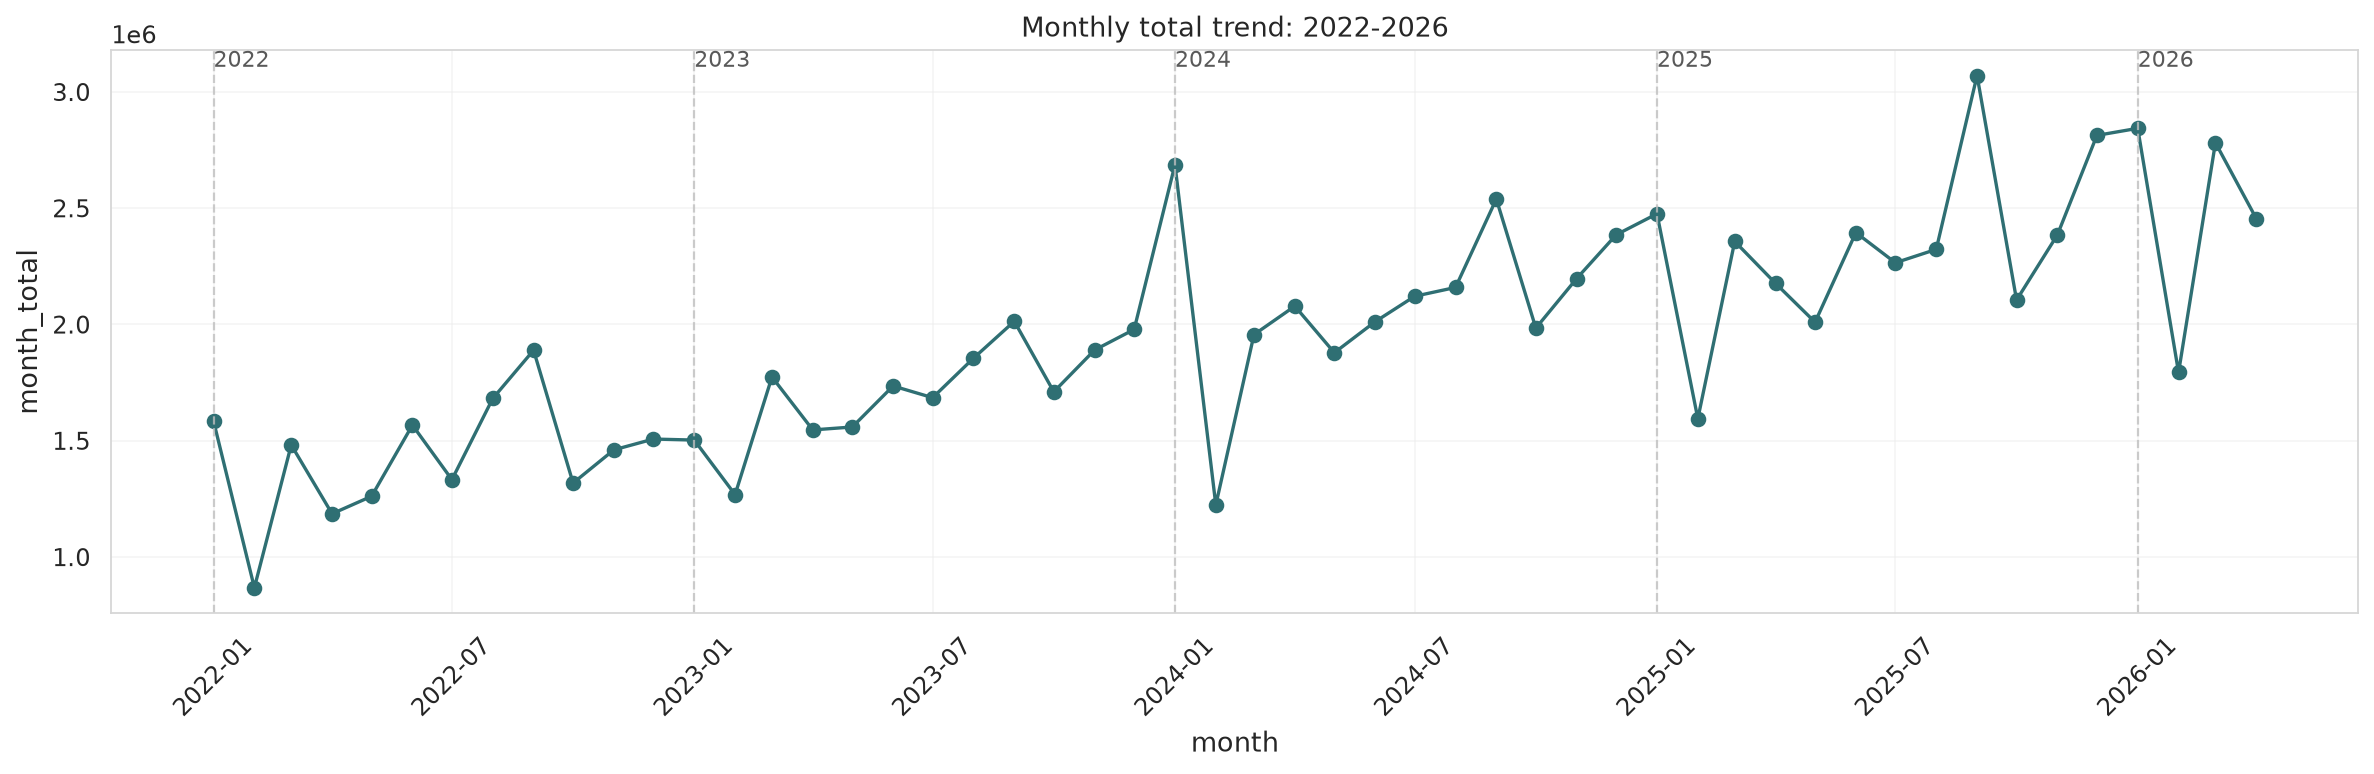

- 目标年份内可观察月数为 52，未来或缺失月份保持 NaN。
- 最高月总量出现在 2025-09，约 3,069,649。
- 最低月总量出现在 2022-02，约 867,247。


In [3]:
month_df = monthly_basic.copy()
month_df = month_df.sort_values("month_start").reset_index(drop=True)
month_df["month_label"] = month_df["month_start"].dt.strftime("%Y-%m")
month_df["prev_month_total"] = month_df["month_total"].shift(1)
month_df["month_total_mom_pct"] = month_df["month_total"] / month_df["prev_month_total"] - 1
month_df["prev_year_bizym"] = (month_df["year"] - 1) * 100 + month_df["month"]
month_df = month_df.merge(
    month_df[["bizym", "month_total"]].rename(columns={"bizym": "prev_year_bizym", "month_total": "prev_year_month_total"}),
    on="prev_year_bizym",
    how="left",
)
month_df["yoy_pct"] = month_df["month_total"] / month_df["prev_year_month_total"] - 1

monthly_target = month_df.query("year in @TARGET_YEARS").copy()
month_total_matrix = (
    monthly_target.pivot(index="year", columns="month", values="month_total")
    .reindex(index=TARGET_YEARS, columns=MONTH_ORDER)
)
month_total_matrix_fmt = month_total_matrix.applymap(fmt_num)
month_total_matrix_fmt.columns = [f"{m:02d}" for m in month_total_matrix_fmt.columns]
display_table(month_total_matrix_fmt, f"{TARGET_YEAR_LABEL} 月总量平铺表")

fig, ax = plt.subplots(figsize=(15, 5))
plot_df = monthly_target.dropna(subset=["month_total"])
ax.plot(plot_df["month_start"], plot_df["month_total"], marker="o", color="#2f6f73")
add_year_boundaries(ax, plot_df)
ax.set_title(f"Monthly total trend: {TARGET_YEAR_LABEL}")
ax.set_xlabel("month")
ax.set_ylabel("month_total")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

valid_months = monthly_target["month_total"].notna().sum()
max_month = monthly_target.loc[monthly_target["month_total"].idxmax()]
min_month = monthly_target.loc[monthly_target["month_total"].idxmin()]
print_insights([
    f"目标年份内可观察月数为 {valid_months}，未来或缺失月份保持 NaN。",
    f"最高月总量出现在 {max_month['month_label']}，约 {fmt_num(max_month['month_total'])}。",
    f"最低月总量出现在 {min_month['month_label']}，约 {fmt_num(min_month['month_total'])}。",
])

## Block 3：连续年份单月总量与按月份对齐对比

表格展示每个自然月在跨年份上的均值、标准差和变异系数；时序图按月份对齐所选年份，观察稳定季节性和年份差异。


自然月跨年季节性 summary


,month,years_observed,avg_month_total,std_month_total,min_month_total,max_month_total,cv_month_total
0,1,5,"2,217,998","630,571","1,502,078","2,842,656",28.4%
1,2,5,"1,348,927","357,649","867,247","1,792,965",26.5%
2,3,5,"2,069,432","508,674","1,481,105","2,780,759",24.6%
3,4,5,"1,887,919","512,662","1,185,194","2,454,706",27.2%
4,5,4,"1,676,349","335,737","1,260,366","2,008,992",20.0%
5,6,4,"1,926,628","361,667","1,566,430","2,394,239",18.8%
6,7,4,"1,850,315","424,623","1,331,894","2,264,622",22.9%
7,8,4,"2,003,895","289,786","1,680,932","2,322,179",14.5%
8,9,4,"2,377,362","540,743","1,888,458","3,069,649",22.7%
9,10,4,"1,778,713","349,131","1,317,266","2,104,318",19.6%


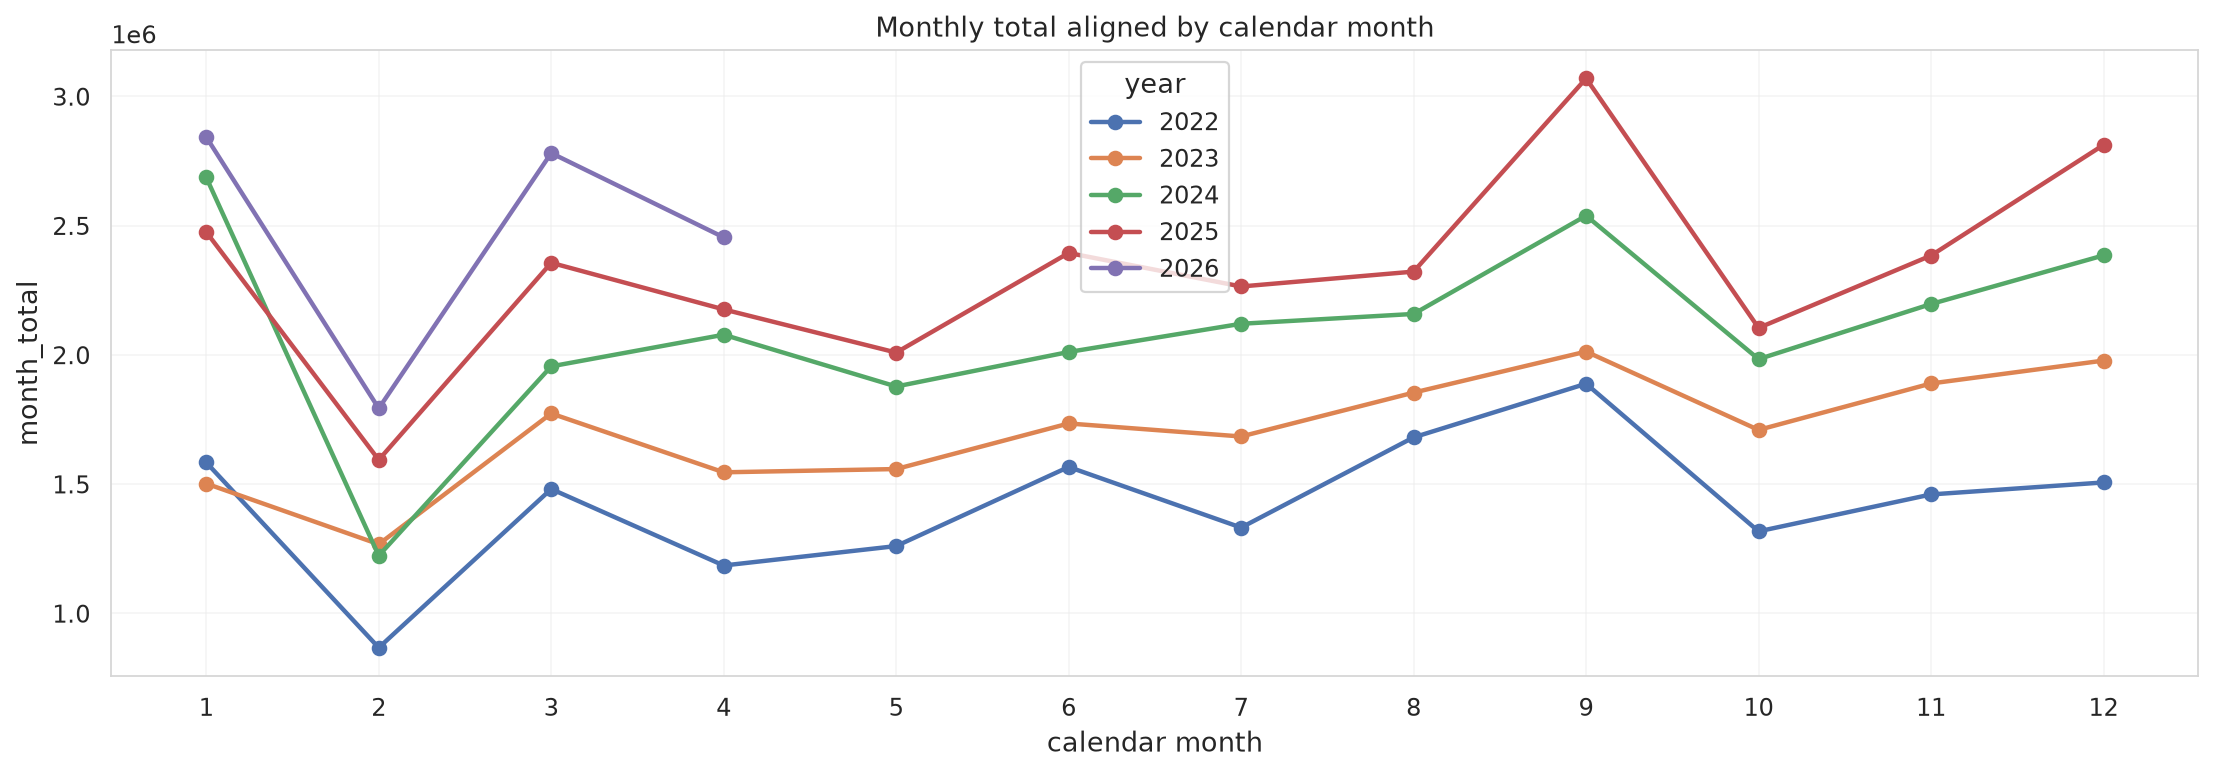

- 按月总量变异系数看，相对稳定月份 Top3：[8, 6, 10]。
- 按月总量变异系数看，波动较大月份 Top3：[1, 4, 2]。
- 该图用于判断自然季节性；真正预测时不能直接使用当月最终总量，只能把历史稳定性转成先验或切片特征。


In [4]:
seasonality_table = (
    monthly_target.groupby("month", as_index=False)
    .agg(
        years_observed=("year", "nunique"),
        avg_month_total=("month_total", "mean"),
        std_month_total=("month_total", "std"),
        min_month_total=("month_total", "min"),
        max_month_total=("month_total", "max"),
    )
    .reindex(columns=["month", "years_observed", "avg_month_total", "std_month_total", "min_month_total", "max_month_total"])
)
seasonality_table["cv_month_total"] = seasonality_table["std_month_total"] / seasonality_table["avg_month_total"]
seasonality_display = seasonality_table.copy()
for c in ["avg_month_total", "std_month_total", "min_month_total", "max_month_total"]:
    seasonality_display[c] = seasonality_display[c].map(fmt_num)
seasonality_display["cv_month_total"] = pct_series(seasonality_table["cv_month_total"])
display_table(seasonality_display, "自然月跨年季节性 summary")

fig, ax = plt.subplots(figsize=(14, 5))
for year, g in monthly_target.groupby("year"):
    ax.plot(g["month"], g["month_total"], marker="o", linewidth=2, label=str(year))
ax.set_xticks(MONTH_ORDER)
ax.set_title("Monthly total aligned by calendar month")
ax.set_xlabel("calendar month")
ax.set_ylabel("month_total")
ax.legend(title="year")
plt.tight_layout()
plt.show()

stable_months = seasonality_table.dropna(subset=["cv_month_total"]).nsmallest(3, "cv_month_total")["month"].tolist()
volatile_months = seasonality_table.dropna(subset=["cv_month_total"]).nlargest(3, "cv_month_total")["month"].tolist()
print_insights([
    f"按月总量变异系数看，相对稳定月份 Top3：{stable_months}。",
    f"按月总量变异系数看，波动较大月份 Top3：{volatile_months}。",
    "该图用于判断自然季节性；真正预测时不能直接使用当月最终总量，只能把历史稳定性转成先验或切片特征。",
])

## Block 4：MoM 环比分析

表格列出环比上涨和下跌最明显的月份；时序图连续展示三年月度 MoM，定位短期跳变。

MoM 平铺表


,01,02,03,04,05,06,07,08,09,10,11,12,Mean
year,,,,,,,,,,,,,
2024,35.8%,-54.5%,59.9%,6.3%,-9.6%,7.1%,5.4%,1.8%,17.6%,-21.9%,10.7%,8.6%,5.6%
2025,3.8%,-35.6%,47.8%,-7.7%,-7.7%,19.2%,-5.4%,2.5%,32.2%,-31.4%,13.3%,17.9%,4.1%
2026,1.1%,-36.9%,55.1%,-11.7%,,,,,,,,,1.9%


MoM Top 上涨 / 下跌月份


,month_label,year,month,month_total,prev_month_total,month_total_mom_pct,rank_type
0,2024-03,2024,3,"1,955,574","1,223,031",59.9%,Top increase
1,2026-03,2026,3,"2,780,759","1,792,965",55.1%,Top increase
2,2025-03,2025,3,"2,356,303","1,593,857",47.8%,Top increase
3,2024-01,2024,1,"2,686,281","1,977,926",35.8%,Top increase
4,2025-09,2025,9,"3,069,649","2,322,179",32.2%,Top increase
5,2025-06,2025,6,"2,394,239","2,008,992",19.2%,Top increase
6,2024-02,2024,2,"1,223,031","2,686,281",-54.5%,Top decrease
7,2026-02,2026,2,"1,792,965","2,842,656",-36.9%,Top decrease
8,2025-02,2025,2,"1,593,857","2,475,234",-35.6%,Top decrease
9,2025-10,2025,10,"2,104,318","3,069,649",-31.4%,Top decrease


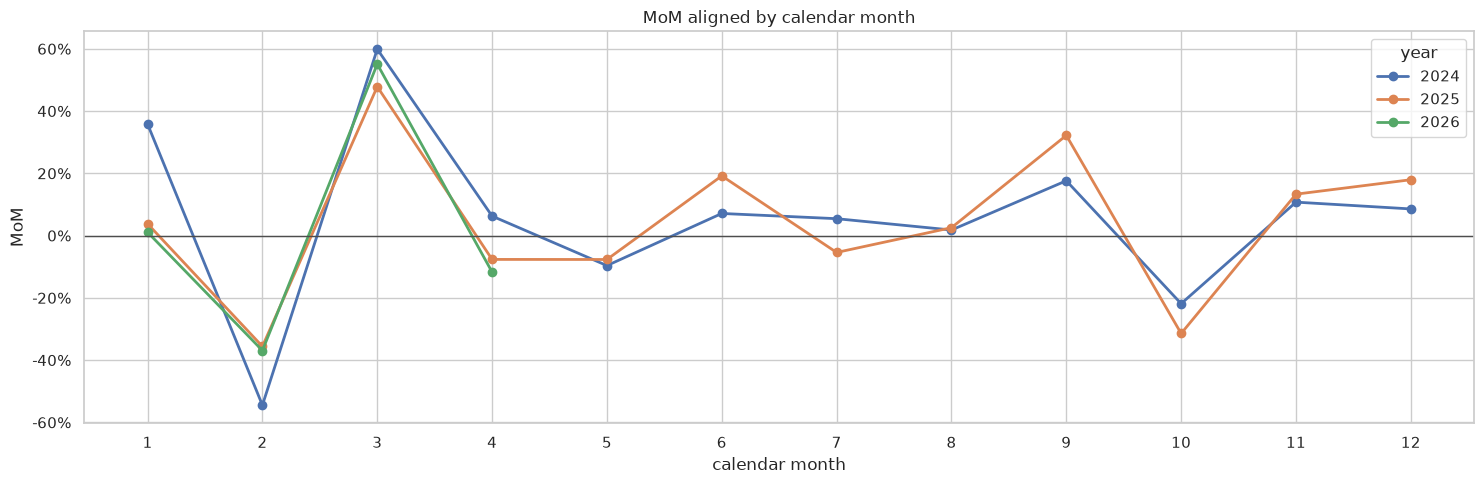

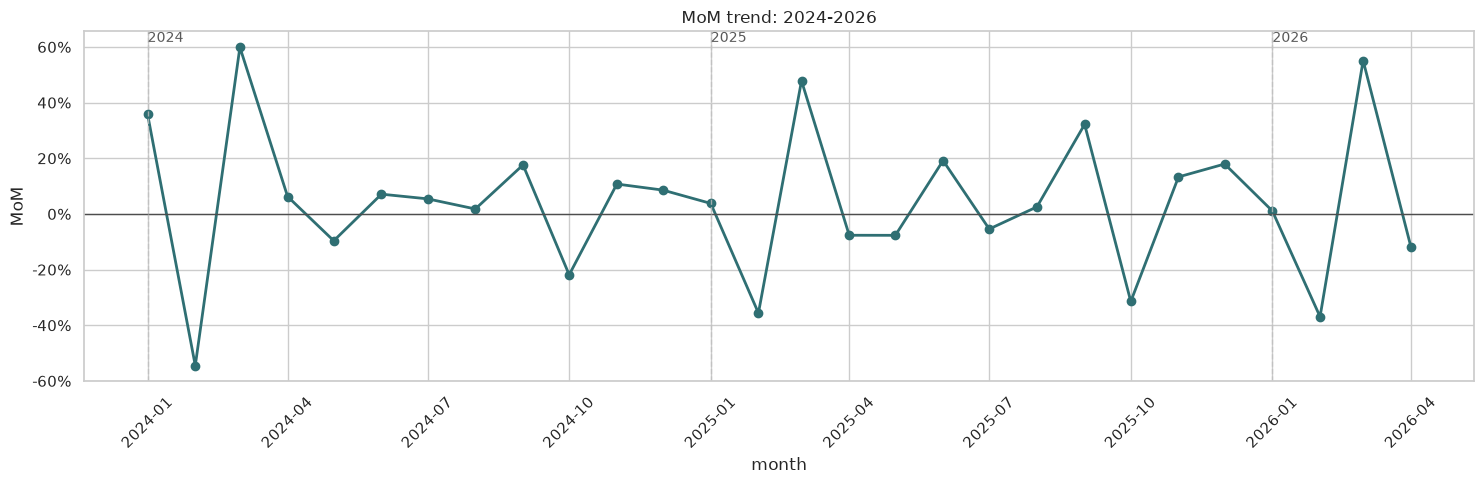

- 最大环比上涨出现在 2024-03，MoM=59.9%。
- 最大环比下跌出现在 2024-02，MoM=-54.5%。
- MoM 对齐图用于比较不同年份同一自然月的环比节奏；连续图用于观察跨月份跳变和年份切换影响。


In [ ]:
mom_df = monthly_target[
    [
        "month_label",
        "month_start",
        "year",
        "month",
        "month_total",
        "prev_month_total",
        "month_total_mom_pct",
    ]
].copy()

mom_matrix = (
    mom_df
    .pivot(index="year", columns="month", values="month_total_mom_pct")
    .reindex(index=TARGET_YEARS, columns=MONTH_ORDER)
)

mom_matrix["Mean"] = mom_matrix.mean(axis=1, skipna=True)

mom_matrix_fmt = mom_matrix.copy()
for col in mom_matrix_fmt.columns:
    mom_matrix_fmt[col] = pct_series(mom_matrix_fmt[col])

mom_matrix_fmt.columns = [
    f"{c:02d}" if isinstance(c, int) else c
    for c in mom_matrix_fmt.columns
]
display_table(mom_matrix_fmt, "MoM 平铺表")

mom_rank = pd.concat([
    mom_df.nlargest(6, "month_total_mom_pct").assign(rank_type="Top increase"),
    mom_df.nsmallest(6, "month_total_mom_pct").assign(rank_type="Top decrease"),
], ignore_index=True)

mom_rank_display = mom_rank.copy()
mom_rank_display["month_total"] = mom_rank_display["month_total"].map(fmt_num)
mom_rank_display["prev_month_total"] = mom_rank_display["prev_month_total"].map(fmt_num)
mom_rank_display["month_total_mom_pct"] = pct_series(mom_rank["month_total_mom_pct"])
display_table(
    mom_rank_display.drop(columns=["month_start"]),
    "MoM Top 上涨 / 下跌月份",
)

# 图 1：按自然月对齐的 MoM 对比图
fig, ax = plt.subplots(figsize=(15, 5))

for year in TARGET_YEARS:
    color = get_year_color(year)
    if year in mom_matrix.index:
        y = mom_matrix.loc[year].drop(labels=["Mean"], errors="ignore")
        ax.plot(
            MONTH_ORDER,
            y.reindex(MONTH_ORDER),
            marker="o",
            linewidth=2,
            label=str(year),
            color=color,
        )

ax.axhline(0, color="0.3", linewidth=1)
ax.set_xticks(MONTH_ORDER)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("MoM aligned by calendar month")
ax.set_xlabel("calendar month")
ax.set_ylabel("MoM")
ax.legend(title="year")
plt.tight_layout()
plt.show()

# 图 2：连续 MoM 时序图，把所选范围串起来
mom_trend_df = (
    mom_df
    .dropna(subset=["month_total_mom_pct"])
    .sort_values("month_start")
    .copy()
)

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    mom_trend_df["month_start"],
    mom_trend_df["month_total_mom_pct"],
    marker="o",
    linewidth=2,
    color="#2f6f73",
)

ax.axhline(0, color="0.3", linewidth=1)

year_starts = (
    mom_trend_df
    .drop_duplicates("year")[["month_start", "year"]]
    .sort_values("month_start")
)

ymin, ymax = ax.get_ylim()
for _, row in year_starts.iterrows():
    ax.axvline(
        row["month_start"],
        color="0.75",
        linewidth=1,
        linestyle="--",
        alpha=0.8,
    )
    ax.text(
        row["month_start"],
        ymax,
        str(int(row["year"])),
        va="top",
        ha="left",
        color="0.35",
        fontsize=10,
    )

ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title(f"MoM trend: {TARGET_YEAR_LABEL}")
ax.set_xlabel("month")
ax.set_ylabel("MoM")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

best = mom_df.loc[mom_df["month_total_mom_pct"].idxmax()]
worst = mom_df.loc[mom_df["month_total_mom_pct"].idxmin()]

print_insights([
    f"最大环比上涨出现在 {best['month_label']}，MoM={fmt_pct(best['month_total_mom_pct'])}。",
    f"最大环比下跌出现在 {worst['month_label']}，MoM={fmt_pct(worst['month_total_mom_pct'])}。",
    "MoM 对齐图用于比较不同年份同一自然月的环比节奏；连续图用于观察跨月份跳变和年份切换影响。",
])

## Block 5：YoY 同比分析

表格按可计算的年度同比组合平铺同比；时序图连续展示可观测月份的 YoY，突出稳定和异常月份。


YoY 平铺表


,01,02,03,04,05,06,07,08,09,10,11,12
compare,,,,,,,,,,,,
2025_vs_2024,-7.9%,30.3%,20.5%,4.7%,7.0%,19.0%,6.8%,7.6%,20.9%,6.1%,8.5%,17.9%
2026_vs_2025,14.8%,12.5%,18.0%,12.8%,,,,,,,,


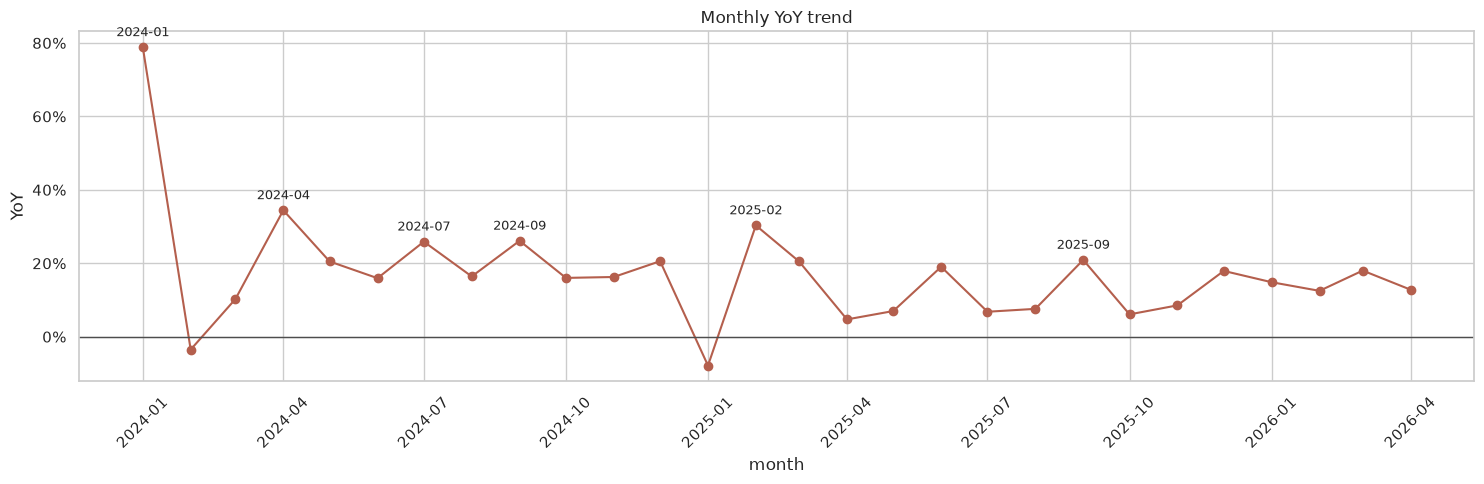

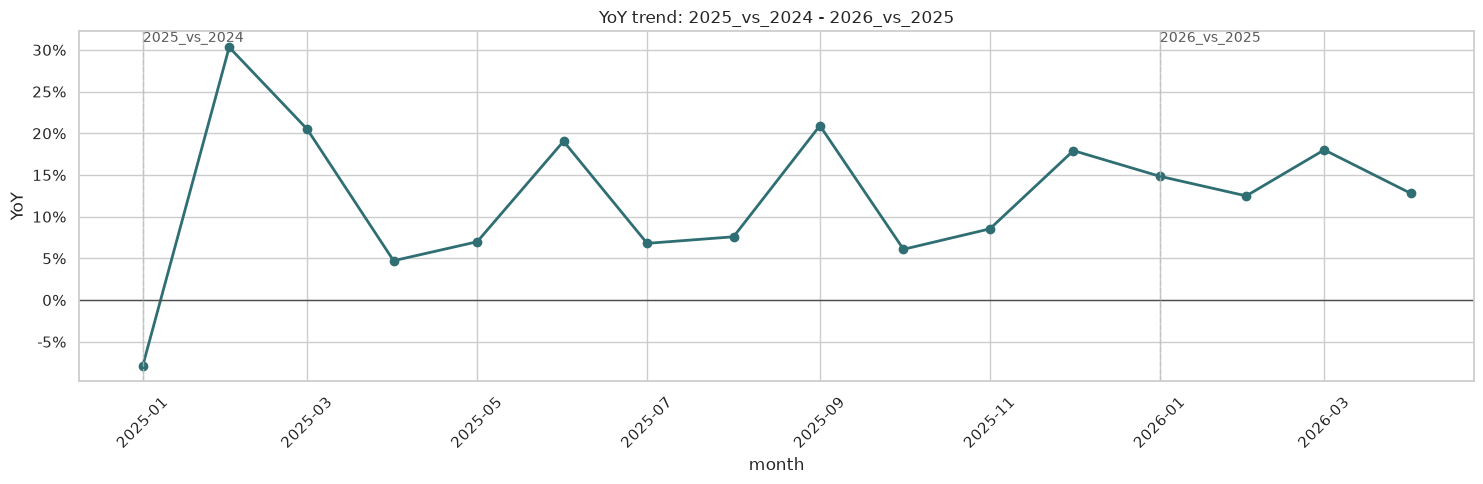

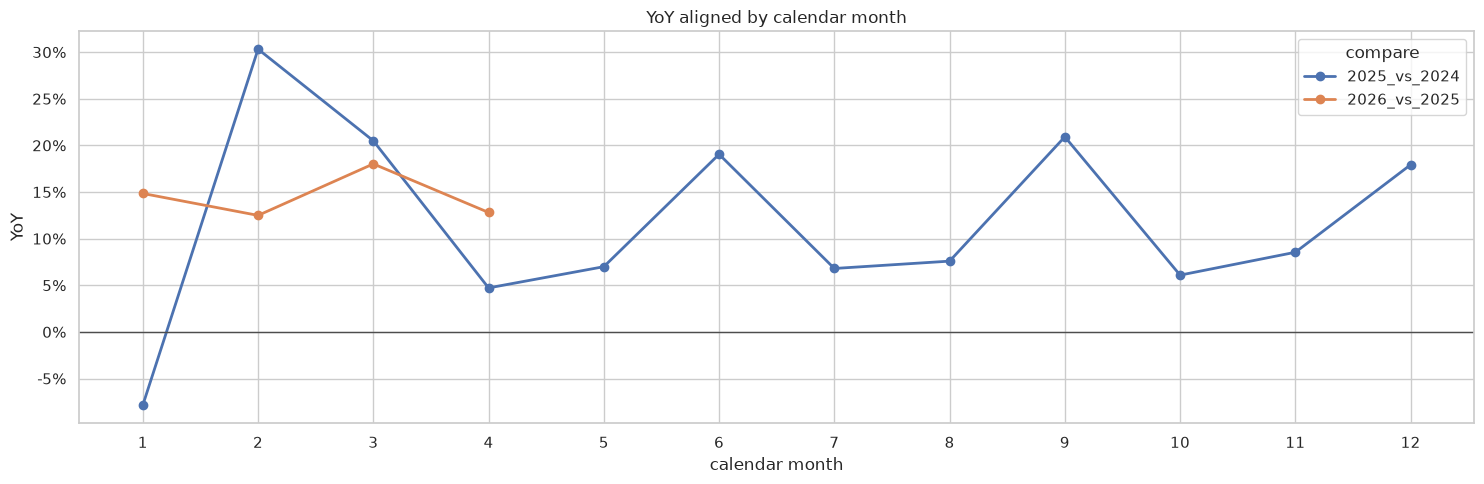

- 最高同比出现在 2024-01，YoY=78.8%。
- 最低同比出现在 2025-01，YoY=-7.9%。
- YoY 连续图按时间串联 2025 vs 2024、2026 vs 2025；底部 YoY 对齐图按 1～12 月比较两组同比，2026 缺失月份保持空值，不补零。


In [ ]:
yoy_df = monthly_target.dropna(subset=["yoy_pct"]).copy()
yoy_df["compare"] = yoy_df["year"].astype(str) + "_vs_" + (yoy_df["year"] - 1).astype(str)

yoy_matrix = (
    yoy_df
    .pivot(index="compare", columns="month", values="yoy_pct")
    .reindex(index=YOY_COMPARE_ORDER, columns=MONTH_ORDER)
)

yoy_matrix_fmt = yoy_matrix.applymap(fmt_pct)
yoy_matrix_fmt.columns = [f"{m:02d}" for m in yoy_matrix_fmt.columns]
display_table(yoy_matrix_fmt, "YoY 平铺表")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(yoy_df["month_start"], yoy_df["yoy_pct"], marker="o", color="#b45f4d")
ax.axhline(0, color="0.3", linewidth=1)

if len(yoy_df) > 0:
    threshold = yoy_df["yoy_pct"].abs().quantile(0.8)
    for _, row in yoy_df.iterrows():
        if abs(row["yoy_pct"]) >= threshold:
            ax.annotate(
                row["month_label"],
                (row["month_start"], row["yoy_pct"]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=9,
            )

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("Monthly YoY trend")
ax.set_xlabel("month")
ax.set_ylabel("YoY")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 新增：YoY 连续时序图，作为倒数第二张图
yoy_trend_df = (
    yoy_df[yoy_df["compare"].isin(YOY_COMPARE_ORDER)]
    .sort_values("month_start")
    .copy()
)

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    yoy_trend_df["month_start"],
    yoy_trend_df["yoy_pct"],
    marker="o",
    linewidth=2,
    color="#2f6f73",
)

ax.axhline(0, color="0.3", linewidth=1)

compare_starts = (
    yoy_trend_df
    .drop_duplicates("compare")[["month_start", "compare"]]
    .sort_values("month_start")
)

ymin, ymax = ax.get_ylim()
for _, row in compare_starts.iterrows():
    ax.axvline(
        row["month_start"],
        color="0.75",
        linewidth=1,
        linestyle="--",
        alpha=0.8,
    )
    ax.text(
        row["month_start"],
        ymax,
        row["compare"],
        va="top",
        ha="left",
        color="0.35",
        fontsize=10,
    )

ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("YoY trend" if not YOY_COMPARE_ORDER else f"YoY trend: {YOY_COMPARE_ORDER[0]} - {YOY_COMPARE_ORDER[-1]}")
ax.set_xlabel("month")
ax.set_ylabel("YoY")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 新增：按自然月对齐的 YoY 对比图，作为最后一张图
fig, ax = plt.subplots(figsize=(15, 5))

for compare in YOY_COMPARE_ORDER:
    color = get_compare_color(compare)
    if compare in yoy_matrix.index:
        y = yoy_matrix.loc[compare]
        ax.plot(
            MONTH_ORDER,
            y.reindex(MONTH_ORDER),
            marker="o",
            linewidth=2,
            label=compare,
            color=color,
        )

ax.axhline(0, color="0.3", linewidth=1)
ax.set_xticks(MONTH_ORDER)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("YoY aligned by calendar month")
ax.set_xlabel("calendar month")
ax.set_ylabel("YoY")
ax.legend(title="compare")
plt.tight_layout()
plt.show()

if not yoy_df.empty:
    strongest = yoy_df.loc[yoy_df["yoy_pct"].idxmax()]
    weakest = yoy_df.loc[yoy_df["yoy_pct"].idxmin()]
    print_insights([
        f"最高同比出现在 {strongest['month_label']}，YoY={fmt_pct(strongest['yoy_pct'])}。",
        f"最低同比出现在 {weakest['month_label']}，YoY={fmt_pct(weakest['yoy_pct'])}。",
        "YoY 连续图按时间串联可计算的年度同比组合；底部 YoY 对齐图按 1～12 月比较各组同比，缺失月份保持空值，不补零。",
    ])
else:
    strongest = weakest = None
    print_insights(["当前目标年份没有足够历史月份计算 YoY。"])

## Block 6：Rolling 趋势

表格展示最近日期的日粒度和月粒度 rolling 指标；时序图展示日销量 7/14/30 日 rolling mean，用来识别长期趋势和短期异常。

最近 12 天 rolling 指标


,transdate,qty,qty_roll_7d,qty_roll_14d,qty_roll_30d,num_hosp,num_hosp_roll_7d,num_hosp_roll_14d,num_hosp_roll_30d
1199,2026-04-19,"1,335","78,766","71,710","82,011",32,527,493,470
1200,2026-04-20,"183,820","80,284","83,690","88,120","1,121",535,566,507
1201,2026-04-21,"119,002","78,775","80,973","91,994",799,530,544,532
1202,2026-04-22,"106,599","81,999","80,943","89,562",597,521,532,516
1203,2026-04-23,"122,908","87,143","82,783","90,020",673,528,531,515
1204,2026-04-24,"95,544","89,947","84,926","89,674",526,539,533,514
1205,2026-04-25,"3,336","90,363","84,811","86,044",18,538,532,495
1206,2026-04-26,"9,361","91,510","85,138","83,528",42,539,533,484
1207,2026-04-27,"193,707","92,922","86,603","89,900","1,104",537,536,520
1208,2026-04-28,"145,717","96,739","87,757","94,674",878,548,539,548


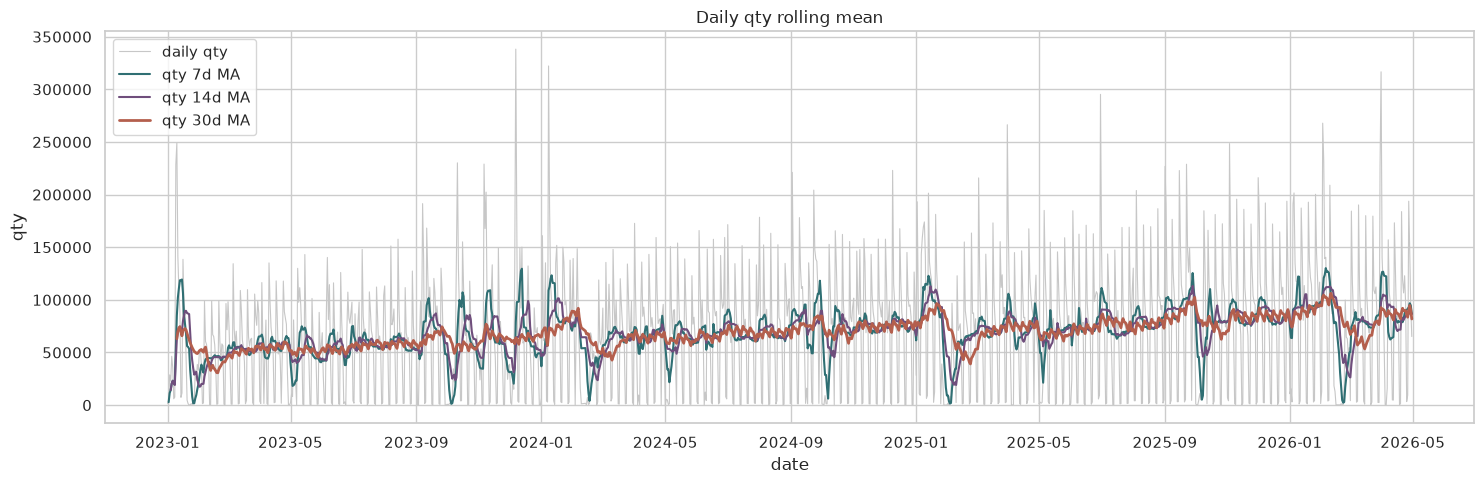

- 最近 30 日 rolling mean 相比窗口初值呈下行或走平。
- 7 日均线更敏感，适合识别短期冲击；30 日均线更适合判断结构趋势。
- rolling 指标用于预测时必须只使用预测锚点及以前的历史数据。


In [ ]:
daily_roll = df.sort_values("transdate").copy()
for w in [7, 14, 30]:
    daily_roll[f"qty_roll_{w}d"] = daily_roll["qty"].rolling(w, min_periods=max(2, w // 3)).mean()
    daily_roll[f"num_hosp_roll_{w}d"] = daily_roll["num_hosp"].rolling(w, min_periods=max(2, w // 3)).mean()

month_roll = month_df.copy()
month_roll["month_total_roll_3m"] = month_roll["month_total"].rolling(3, min_periods=2).mean()
rolling_table = daily_roll[["transdate", "qty", "qty_roll_7d", "qty_roll_14d", "qty_roll_30d", "num_hosp", "num_hosp_roll_7d", "num_hosp_roll_14d", "num_hosp_roll_30d"]].tail(12).copy()
for c in rolling_table.columns:
    if c != "transdate":
        rolling_table[c] = rolling_table[c].map(fmt_num)
display_table(rolling_table, "最近 12 天 rolling 指标")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily_roll["transdate"], daily_roll["qty"], color="0.78", linewidth=0.8, label="daily qty")
ax.plot(daily_roll["transdate"], daily_roll["qty_roll_7d"], linewidth=1.5, label="qty 7d MA", color="#2f6f73")
ax.plot(daily_roll["transdate"], daily_roll["qty_roll_14d"], linewidth=1.5, label="qty 14d MA", color="#6f4e7c")
ax.plot(daily_roll["transdate"], daily_roll["qty_roll_30d"], linewidth=2.0, label="qty 30d MA", color="#b45f4d")
ax.set_title("Daily qty rolling mean")
ax.set_xlabel("date")
ax.set_ylabel("qty")
ax.legend()
plt.tight_layout()
plt.show()

recent_30 = daily_roll.dropna(subset=["qty_roll_30d"]).tail(30)
trend_msg = "上行" if recent_30["qty_roll_30d"].iloc[-1] > recent_30["qty_roll_30d"].iloc[0] else "下行或走平"
print_insights([
    f"最近 30 日 rolling mean 相比窗口初值呈{trend_msg}。",
    "7 日均线更敏感，适合识别短期冲击；30 日均线更适合判断结构趋势。",
    "rolling 指标用于预测时必须只使用预测锚点及以前的历史数据。",
])

## Block 7：月内累计节奏分析

表格只输出倒数第 10 / 第 5 工作日两个预测锚点的累计占比；时序图展示平稳月份 7 月与不平稳月份 1/2/3 月的月内累计曲线。


倒数第 5 个工作日累计占比分析
倒数第 5 个工作日累计占比平铺表


,01,02,03,04,05,06,07,08,09,10,11,12,Mean,Mean Abs Gap To 100%
year,,,,,,,,,,,,,,
2024,85.3%,75.1%,82.3%,81.3%,84.6%,77.0%,82.0%,81.7%,77.4%,79.1%,83.0%,83.1%,81.0%,19.0%
2025,100.0%,79.8%,75.6%,80.2%,81.5%,73.8%,79.5%,82.9%,81.1%,82.1%,81.9%,82.1%,81.7%,18.3%
2026,83.2%,81.6%,73.2%,79.2%,,,,,,,,,79.3%,20.7%


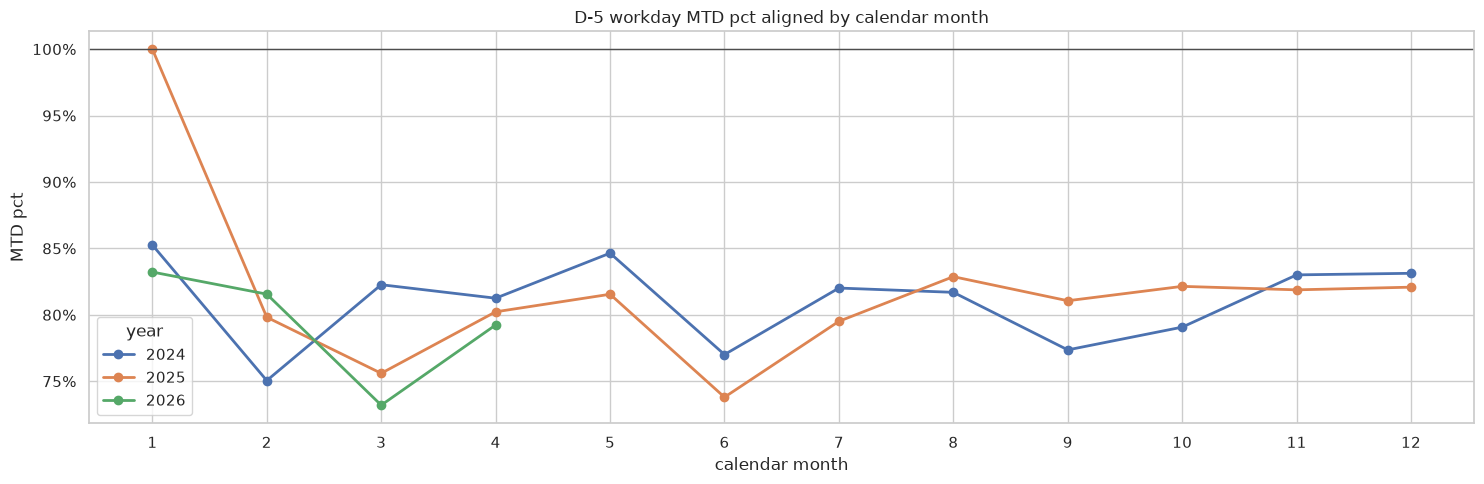

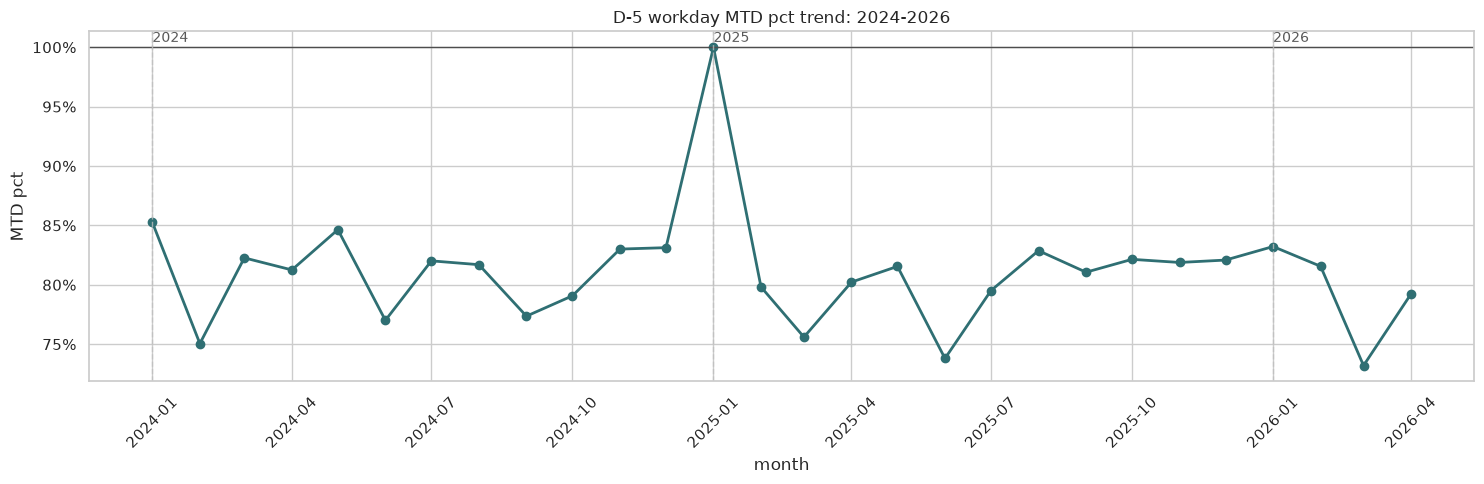

- 倒数第 5 个工作日累计占比最高出现在 2025-01，MTD=100.0%。
- 倒数第 5 个工作日累计占比最低出现在 2026-03，MTD=73.2%。
- D-5 锚点累计占比越稳定，越适合用历史月内节奏反推全月总量；波动大的月份建议单独做误差切片。

倒数第 10 个工作日累计占比分析
倒数第 10 个工作日累计占比平铺表


,01,02,03,04,05,06,07,08,09,10,11,12,Mean,Mean Abs Gap To 100%
year,,,,,,,,,,,,,,
2024,64.2%,49.1%,60.2%,57.0%,62.0%,53.6%,61.7%,62.0%,50.6%,54.8%,60.4%,62.5%,58.2%,41.8%
2025,81.7%,50.2%,55.0%,54.9%,56.0%,53.2%,57.8%,59.9%,57.6%,56.0%,59.8%,61.4%,58.6%,41.4%
2026,59.7%,78.7%,53.8%,53.6%,,,,,,,,,61.4%,38.6%


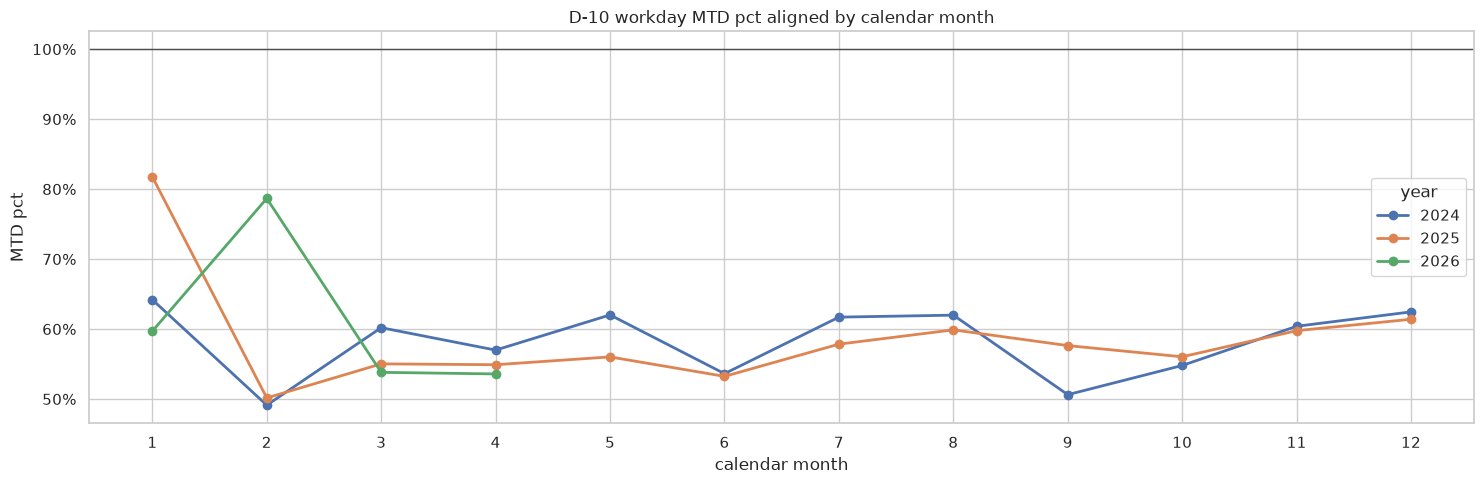

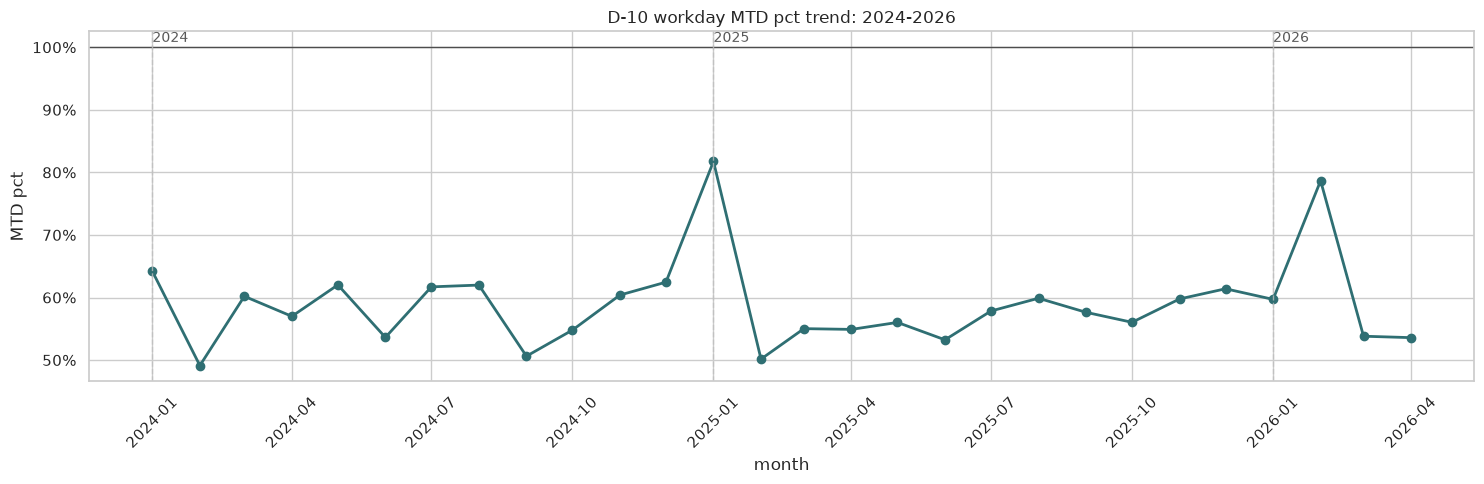

- 倒数第 10 个工作日累计占比最高出现在 2025-01，MTD=81.7%。
- 倒数第 10 个工作日累计占比最低出现在 2024-02，MTD=49.1%。
- D-10 锚点累计占比越稳定，越适合用历史月内节奏反推全月总量；波动大的月份建议单独做误差切片。


In [ ]:
daily = df.copy()
daily["month_start"] = daily["transdate"].dt.to_period("M").dt.to_timestamp()
daily["month_label"] = daily["month_start"].dt.strftime("%Y-%m")

daily["is_workday"] = daily["transdate"].map(is_business_workday)
daily["workday_seq"] = (
    daily
    .groupby("bizym")["is_workday"]
    .cumsum()
    .where(daily["is_workday"], np.nan)
)

month_workdays = (
    daily
    .groupby("bizym", as_index=False)
    .agg(max_workday_seq=("workday_seq", "max"))
)

daily = daily.merge(month_workdays, on="bizym", how="left")
daily["workdays_to_month_end"] = daily["max_workday_seq"] - daily["workday_seq"]
daily["mtd_qty"] = daily.groupby("bizym")["qty"].cumsum()
daily = daily.merge(month_df[["bizym", "month_total"]], on="bizym", how="left")
daily["mtd_pct"] = daily["mtd_qty"] / daily["month_total"]
daily["days_to_month_end"] = daily["transdate"].dt.days_in_month - daily["day_of_month"]

anchor_rows = daily[
    daily["is_workday"]
    & daily["workdays_to_month_end"].isin([offset - 1 for offset in [5, 10]])
    & daily["year"].isin(TARGET_YEARS)
].copy()

anchor_rows["forecast_offset"] = anchor_rows["workdays_to_month_end"].astype(int) + 1

anchor_table = anchor_rows[
    [
        "year",
        "month",
        "bizym",
        "month_start",
        "month_label",
        "transdate",
        "forecast_offset",
        "workday_seq",
        "max_workday_seq",
        "mtd_qty",
        "month_total",
        "mtd_pct",
    ]
].sort_values(["forecast_offset", "year", "month"])

for forecast_offset in [5, 10]:
    offset_df = (
        anchor_table
        .query("forecast_offset == @forecast_offset")
        .sort_values("month_start")
        .copy()
    )

    print(f"\n倒数第 {forecast_offset} 个工作日累计占比分析")

    offset_matrix = (
        offset_df
        .pivot(index="year", columns="month", values="mtd_pct")
        .reindex(index=TARGET_YEARS, columns=MONTH_ORDER)
    )

    offset_matrix["Mean"] = offset_matrix.mean(axis=1, skipna=True)
    offset_matrix["Mean Abs Gap To 100%"] = (
        1 - offset_matrix[MONTH_ORDER]
    ).abs().mean(axis=1, skipna=True)

    offset_matrix_fmt = offset_matrix.copy()
    for col in offset_matrix_fmt.columns:
        offset_matrix_fmt[col] = pct_series(offset_matrix_fmt[col])

    offset_matrix_fmt.columns = [
        f"{c:02d}" if isinstance(c, int) else c
        for c in offset_matrix_fmt.columns
    ]

    display_table(
        offset_matrix_fmt,
        f"倒数第 {forecast_offset} 个工作日累计占比平铺表",
    )

    # 图 1：按自然月对齐，比较不同年份同一个月份在该锚点的累计占比
    fig, ax = plt.subplots(figsize=(15, 5))

    for year in TARGET_YEARS:
        color = get_year_color(year)
        if year in offset_matrix.index:
            y = offset_matrix.loc[year].drop(
                labels=["Mean", "Mean Abs Gap To 100%"],
                errors="ignore",
            )
            ax.plot(
                MONTH_ORDER,
                y.reindex(MONTH_ORDER),
                marker="o",
                linewidth=2,
                label=str(year),
                color=color,
            )

    ax.axhline(1, color="0.3", linewidth=1)
    ax.set_xticks(MONTH_ORDER)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(f"D-{forecast_offset} workday MTD pct aligned by calendar month")
    ax.set_xlabel("calendar month")
    ax.set_ylabel("MTD pct")
    ax.legend(title="year")
    plt.tight_layout()
    plt.show()

    # 图 2：连续时序图，把所选范围串起来
    fig, ax = plt.subplots(figsize=(15, 5))

    ax.plot(
        offset_df["month_start"],
        offset_df["mtd_pct"],
        marker="o",
        linewidth=2,
        color="#2f6f73",
    )

    ax.axhline(1, color="0.3", linewidth=1)

    year_starts = (
        offset_df
        .drop_duplicates("year")[["month_start", "year"]]
        .sort_values("month_start")
    )

    ymin, ymax = ax.get_ylim()
    for _, row in year_starts.iterrows():
        ax.axvline(
            row["month_start"],
            color="0.75",
            linewidth=1,
            linestyle="--",
            alpha=0.8,
        )
        ax.text(
            row["month_start"],
            ymax,
            str(int(row["year"])),
            va="top",
            ha="left",
            color="0.35",
            fontsize=10,
        )

    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(f"D-{forecast_offset} workday MTD pct trend: {TARGET_YEAR_LABEL}")
    ax.set_xlabel("month")
    ax.set_ylabel("MTD pct")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    offset_best = offset_df.loc[offset_df["mtd_pct"].idxmax()]
    offset_worst = offset_df.loc[offset_df["mtd_pct"].idxmin()]

    print_insights([
        f"倒数第 {forecast_offset} 个工作日累计占比最高出现在 {offset_best['month_label']}，MTD={fmt_pct(offset_best['mtd_pct'])}。",
        f"倒数第 {forecast_offset} 个工作日累计占比最低出现在 {offset_worst['month_label']}，MTD={fmt_pct(offset_worst['mtd_pct'])}。",
        f"D-{forecast_offset} 锚点累计占比越稳定，越适合用历史月内节奏反推全月总量；波动大的月份建议单独做误差切片。",
    ])

## Block 8：稳定性评分

表格给出每个自然月的月总量 YoY 波动、月内曲线波动和两个预测锚点波动；时序图展示每月稳定性评分，分数越低表示越稳定。

自然月稳定性评分


,month,yoy_std,yoy_iqr,curve_mtd_pct_std_avg,anchor_d10_mtd_pct_std,anchor_d5_mtd_pct_std,stability_risk_score,stability_bucket
0,1,45.0%,43.3%,6.0%,11.6%,9.2%,77.4%,volatile
1,2,16.9%,16.9%,12.9%,16.8%,3.4%,66.5%,volatile
2,3,5.3%,5.1%,4.5%,3.4%,4.7%,25.6%,volatile
3,4,15.4%,14.9%,1.4%,1.7%,1.0%,11.3%,medium
4,5,9.5%,6.8%,1.5%,4.2%,2.2%,15.4%,volatile
5,6,2.2%,1.6%,4.0%,0.3%,2.3%,10.7%,medium
6,7,13.5%,9.5%,1.2%,2.7%,1.8%,13.5%,medium
7,8,6.2%,4.4%,1.9%,1.5%,0.8%,6.1%,stable
8,9,3.7%,2.6%,1.5%,5.0%,2.6%,14.3%,medium
9,10,7.0%,5.0%,1.3%,0.9%,2.2%,8.4%,stable


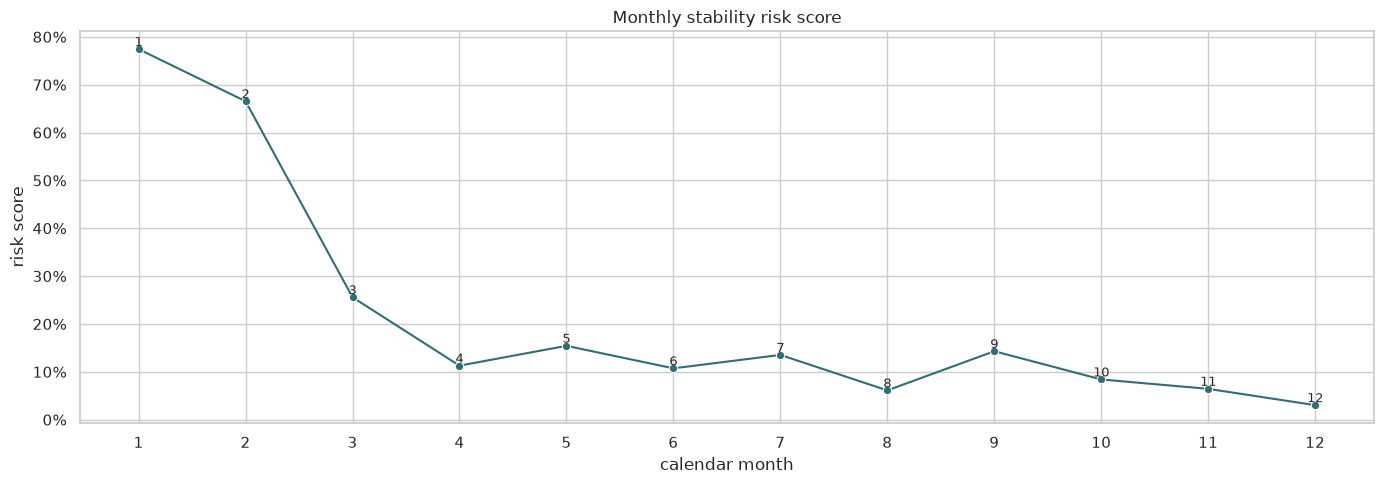

- 稳定性较高月份：[12, 8, 11, 10]。
- 波动风险较高月份：[1, 2, 3, 5]。
- 该评分是 EDA 诊断指标，不直接作为标签；建模时可转化为 month、season、anchor_mtd_pct 历史稳定性等特征。


In [ ]:
curve_stability = (
    daily.query("year in @TARGET_YEARS and is_workday")
    .groupby(["month", "workday_seq"])["mtd_pct"]
    .std()
    .groupby("month")
    .mean()
    .rename("curve_mtd_pct_std_avg")
    .reset_index()
)

yoy_stability = (
    yoy_df.groupby("month", as_index=False)
    .agg(yoy_std=("yoy_pct", "std"), yoy_iqr=("yoy_pct", lambda s: s.quantile(0.75) - s.quantile(0.25)))
)

anchor_wide = anchor_stability.pivot(index="month", columns="forecast_offset", values="anchor_mtd_pct_std").reset_index()
anchor_wide = anchor_wide.rename(columns={5: "anchor_d5_mtd_pct_std", 10: "anchor_d10_mtd_pct_std"})

stability = pd.DataFrame({"month": MONTH_ORDER})
stability = stability.merge(yoy_stability, on="month", how="left")
stability = stability.merge(curve_stability, on="month", how="left")
stability = stability.merge(anchor_wide, on="month", how="left")
score_cols = ["yoy_std", "curve_mtd_pct_std_avg", "anchor_d10_mtd_pct_std", "anchor_d5_mtd_pct_std"]
for c in score_cols:
    denom = stability[c].max(skipna=True) - stability[c].min(skipna=True)
    stability[f"{c}_norm"] = (stability[c] - stability[c].min(skipna=True)) / denom if denom and not pd.isna(denom) else np.nan
stability["stability_risk_score"] = stability[[f"{c}_norm" for c in score_cols]].mean(axis=1)
stability["stability_bucket"] = pd.qcut(stability["stability_risk_score"], q=3, labels=["stable", "medium", "volatile"], duplicates="drop")

stability_display = stability[["month", "yoy_std", "yoy_iqr", "curve_mtd_pct_std_avg", "anchor_d10_mtd_pct_std", "anchor_d5_mtd_pct_std", "stability_risk_score", "stability_bucket"]].copy()
for c in ["yoy_std", "yoy_iqr", "curve_mtd_pct_std_avg", "anchor_d10_mtd_pct_std", "anchor_d5_mtd_pct_std", "stability_risk_score"]:
    stability_display[c] = pct_series(stability_display[c])
display_table(stability_display, "自然月稳定性评分")

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=stability, x="month", y="stability_risk_score", marker="o", ax=ax, color="#2f6f73")
for _, row in stability.dropna(subset=["stability_risk_score"]).iterrows():
    ax.text(row["month"], row["stability_risk_score"], str(int(row["month"])), ha="center", va="bottom", fontsize=9)
ax.set_xticks(MONTH_ORDER)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("Monthly stability risk score")
ax.set_xlabel("calendar month")
ax.set_ylabel("risk score")
plt.tight_layout()
plt.show()

stable = stability.dropna(subset=["stability_risk_score"]).nsmallest(4, "stability_risk_score")["month"].astype(int).tolist()
volatile = stability.dropna(subset=["stability_risk_score"]).nlargest(4, "stability_risk_score")["month"].astype(int).tolist()
print_insights([
    f"稳定性较高月份：{stable}。",
    f"波动风险较高月份：{volatile}。",
    "该评分是 EDA 诊断指标，不直接作为标签；建模时可转化为 month、season、anchor_mtd_pct 历史稳定性等特征。",
])

## Block 9：EDA Insight 总结与建模建议

本 block 汇总前面表格和图形结论。它以 summary 表为主，不再额外构造新的时序图，避免重复展示。

In [ ]:
summary_rows = []

yearly = monthly_target.groupby("year", as_index=False).agg(year_total=("month_total", "sum"), observed_months=("month_total", "count"))
for _, row in yearly.iterrows():
    summary_rows.append({"topic": "总体趋势", "finding": f"{int(row.year)} 年已观察 {int(row.observed_months)} 个月，总量 {fmt_num(row.year_total)}"})

high_months = seasonality_table.nlargest(3, "avg_month_total")["month"].astype(int).tolist()
low_months = seasonality_table.nsmallest(3, "avg_month_total")["month"].astype(int).tolist()
summary_rows.append({"topic": "季节性", "finding": f"平均月总量较高月份：{high_months}；较低月份：{low_months}"})

if not yoy_df.empty:
    summary_rows.append({"topic": "YoY", "finding": f"同比最高 {strongest['month_label']} ({fmt_pct(strongest['yoy_pct'])})；同比最低 {weakest['month_label']} ({fmt_pct(weakest['yoy_pct'])})"})
summary_rows.append({"topic": "MoM", "finding": f"环比最大上涨 {best['month_label']} ({fmt_pct(best['month_total_mom_pct'])})；最大下跌 {worst['month_label']} ({fmt_pct(worst['month_total_mom_pct'])})"})
summary_rows.append({"topic": "Rolling", "finding": f"最近 30 日 rolling mean 呈{trend_msg}；短期异常更适合用 7/14 日 rolling 观察"})
summary_rows.append({"topic": "月内节奏", "finding": "月末相关分析仅保留倒数第 10 / 第 5 工作日两个预测锚点；7 月用于平稳代表，1/2/3 月用于春节和工作日扰动代表"})
summary_rows.append({"topic": "稳定性", "finding": f"稳定月份候选 {stable}；高风险月份候选 {volatile}"})
summary_rows.append({"topic": "建模建议", "finding": "新增 month、quarter、anchor_offset、anchor_mtd_pct、anchor_workday_seq、remaining_workdays、历史同月锚点累计占比均值/标准差、rolling qty/num_hosp 等特征"})
summary_rows.append({"topic": "切片评估", "finding": "按 forecast_offset=5/10、自然月、稳定性分桶、1/2/3 月、7 月分别汇报 MAPE"})
summary_rows.append({"topic": "泄露边界", "finding": "actual_month_total、月末最终累计占比、预测锚点之后的真实销量只能用于 EDA 或评估，不能进入预测时特征"})

summary_df = pd.DataFrame(summary_rows)
display_table(summary_df, "EDA insight summary")

print_insights([
    "下一步可把锚点累计占比表与 train/valid/test 的 forecast_offset 样本合并，检查模型在 D-10 与 D-5 的误差差异。",
    "若安装 chinese_calendar 后重跑，工作日锚点会更贴近业务日历，尤其影响春节附近的 1/2/3 月。",
])

EDA insight summary


,topic,finding
0,总体趋势,"2024 年已观察 12 个月，总量 25,214,315"
1,总体趋势,"2025 年已观察 12 个月，总量 27,962,013"
2,总体趋势,"2026 年已观察 4 个月，总量 9,871,086"
3,季节性,"平均月总量较高月份：[9, 1, 12]；较低月份：[2, 5, 10]"
4,YoY,同比最高 2024-01 (78.8%)；同比最低 2025-01 (-7.9%)
5,MoM,环比最大上涨 2024-03 (59.9%)；最大下跌 2024-02 (-54.5%)
6,Rolling,最近 30 日 rolling mean 呈下行或走平；短期异常更适合用 7/14 日 ro...
7,月内节奏,月末相关分析仅保留倒数第 10 / 第 5 工作日两个预测锚点；7 月用于平稳代表，1/2/...
8,稳定性,"稳定月份候选 [12, 8, 11, 10]；高风险月份候选 [1, 2, 3, 5]"
9,建模建议,新增 month、quarter、anchor_offset、anchor_mtd_pct、...


- 下一步可把锚点累计占比表与 train/valid/test 的 forecast_offset 样本合并，检查模型在 D-10 与 D-5 的误差差异。
- 若安装 chinese_calendar 后重跑，工作日锚点会更贴近业务日历，尤其影响春节附近的 1/2/3 月。
